/home/emastr/anaconda3/envs/pimlenv/lib/python3.12/site-packages/numpy/lib/function_base.py:2455: RuntimeWarning: divide by zero encountered in <lambda> (vectorized)
  outputs = ufunc(*inputs)
/home/emastr/anaconda3/envs/pimlenv/lib/python3.12/site-packages/numpy/lib/function_base.py:2455: RuntimeWarning: invalid value encountered in <lambda> (vectorized)
  outputs = ufunc(*inputs)


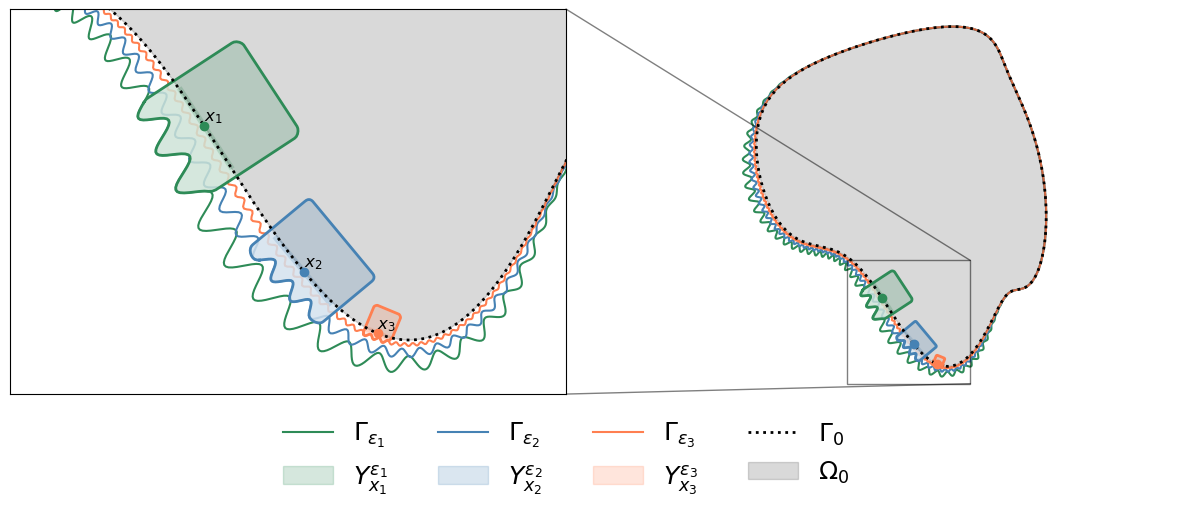

In [13]:
import jax
import numpy as np
from jax import numpy as jnp
from jax import random
from jax import grad, jit, vmap
import matplotlib.pyplot as plt
from boundary_solvers.geometry import RoundedMicroGeomGenericV2

figures_dir = "/home/emastr/deep-micro-slip-model/data/figures/"

import numpy as np
import matplotlib
matplotlib.rcParams['figure.figsize'] = (8,8)
matplotlib.rcParams['font.size'] = 18
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['text.usetex'] = False
matplotlib.rcParams['lines.linewidth'] = 2

sigmoid = lambda x: 1 / (1 + jnp.exp(-x))
get_fourier_series = lambda coeffs: lambda t: jnp.sum(coeffs * jnp.exp(1j * jnp.arange(-(len(coeffs)-1)//2, (len(coeffs)-1)//2+1) * t))

nop = (-1-1j)*5
zp = -0.3 -0.3j
smooth_quadrant_mask = lambda z: sigmoid(jnp.real((z-zp) * jnp.conj(nop)))

def get_random_fourier_series(K, seed=11):
    key = random.PRNGKey(seed)
    key1, key2 = random.split(key)
    freq = jnp.arange(-K, K+1)
    coeffs = (random.normal(key1, (2*K+1,)) + 1j * random.normal(key2, (2*K+1,))) / (jnp.abs(freq)+1)**0.5 * 0.1
    coeffs = coeffs.at[K+1].set(1.)
    return get_fourier_series(coeffs)

fs = get_random_fourier_series(5, 11)
fs_grad = grad(fs, holomorphic=True)
ns = lambda t: fs_grad(t) / 1j
phi = lambda t: (3.+jnp.sin(t*3.))

fs_eps = lambda eps: lambda t: fs(t) + phi(t/eps) * ns(t) * smooth_quadrant_mask(fs(t)) * eps**1.5 * 5

def fill(x, y, *args, **lwargs):
    plt.fill(np.concatenate([x, [x[0]]]), np.concatenate([y, [y[0]]]), *args, **lwargs)
    

def plot_figure(ax, text=False):
    t = jnp.linspace(0, 2*jnp.pi, 2000, dtype=jnp.complex64)
    #t = jnp.linspace(1.30*jnp.pi,1.35*jnp.pi, 2000, dtype=jnp.complex64)
    z = vmap(fs)(t)
    for i, (eps, c) in enumerate(zip([0.03, 0.02, 0.01], ["seagreen", "steelblue", "coral"])):#, 0.07]:
        z_new = vmap(fs_eps(eps))(t)
        plt.plot(z_new.real, z_new.imag, c, linewidth=1.5, label="$\\Gamma_{\\epsilon_" + f"{i+1}" + "}$")    
        
        
        
        t_shift = i*jnp.pi/10 * (eps/0.03)**0.2
        a = 1.3*jnp.pi + t_shift
        b = 1.3*jnp.pi + 0.053*jnp.pi*eps/0.03 + t_shift
        reparam = lambda t, a, b: t*(b-a)/(0.5*np.pi) + a
        f = lambda t: fs_eps(eps)(reparam(t, a, b))
        df = grad(f, holomorphic=True)
        ddf = grad(df, holomorphic=True)

        tc = (a+b)/2 + 0j
        center =  fs(tc)
        corner_w = 1.*eps
        height = eps*5
        normal = fs_grad(tc) / abs(fs_grad(tc)) / 1j
        geom = RoundedMicroGeomGenericV2(*[vectorize_cplx(f_) for f_ in [f, df, ddf]], center, height, normal, corner_w)
        z_geom = geom.eval_param()
        fill(z_geom.real, z_geom.imag, color="white", alpha=.8, zorder=98)#, label="$Y^{\\epsilon_"+ f"{i+1}" +"}_{x_{" + f"{i+1}" + "}}$")
        fill(z_geom.real, z_geom.imag, color=c, alpha=.2, zorder=100, label="$Y^{\\epsilon_"+ f"{i+1}" +"}_{x_{" + f"{i+1}" + "}}$")
        plt.scatter(center.real, center.imag, color=c, zorder=103)
        if text:
            plt.text(center.real+0.02, center.imag+0.02, "$x_{" + f"{i+1}" + "}$", fontsize=12, color="black", ha='center', va='center', zorder=110)
        #plt.fill_between(z_geom.real, z_geom.imag, color=c, alpha=0.5)
        geom.plot(plt.gca(), color=c, zorder=101)
    plt.plot(z.real, z.imag, 'k:', linewidth=2, zorder=102, label="$\\Gamma_0$")
    fill(z.real, z.imag, color="black", alpha=0.15, zorder=99, label="$\\Omega_0$")
    plt.xticks([])
    plt.yticks([])
   

def vectorize_cplx(f):
    f_lambda = lambda t: f(t + 1j*0)
    return np.vectorize(f_lambda)


# plotting
plt.figure(figsize=(15, 5))
#plt.quiver(z.real, z.imag, dz.real, dz.imag)
ax = plt.subplot2grid((2,4),(0,2), colspan=2, rowspan=2)
plot_figure(ax, False)
plt.axis('equal')
plt.axis("off")

 
ax_zoom = plt.subplot2grid((2,4), (0,0), rowspan=2, colspan=2)
plot_figure(ax_zoom, True)
#geom.plot(plt.gca(), color="black", linewidth=3)
plt.axis('equal')
plt.xlim(-0.45, 0.4)
plt.ylim(-1.25, -0.4)
ax.indicate_inset_zoom(ax_zoom, edgecolor="black")

ax_zoom.legend(loc='upper center', bbox_to_anchor=(1., -0.01), ncol=4, frameon=False)

plt.gcf().savefig(f"{figures_dir}/illustration.pdf", bbox_inches='tight')